## Exploratory Data Analysis (EDA) and Machine Learning on Agricultural Yield Dataset

##Import Libraries

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##Part A: Understanding the Dataset
###Q1. Dataset Overview

1. How many rows and columns are present?

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/mahiich07/Agricultural-Yield-EDA-ML/refs/heads/main/agricultural_yield.csv"

df = pd.read_csv(url)

df.shape

(20, 6)

2. What are the names of all columns?

In [4]:
df.columns

Index(['crop_type', 'soil_type', 'rainfall_mm', 'temperature_c',
       'fertilizer_kg', 'yield_ton_per_hectare'],
      dtype='object')

3. Display the first 10 records.

In [5]:
df.head(10)

,crop_type,soil_type,rainfall_mm,temperature_c,fertilizer_kg,yield_ton_per_hectare
0,Rice,Clay,1200,28,150,4.5
1,Wheat,Loamy,700,22,100,3.2
2,Maize,Sandy,850,25,120,3.8
3,Rice,Clay,1300,29,160,4.8
4,Sugarcane,Loamy,1500,30,200,6.5
5,Cotton,Sandy,600,27,90,2.9
6,Wheat,Clay,750,21,110,3.5
7,Maize,Loamy,900,26,130,4.0
8,Rice,Clay,1250,28,155,4.7
9,Cotton,Sandy,650,26,95,3.0


###Q2. Data Types and Missing Values
1. Check the data type of each column.

In [6]:
df.dtypes

,0
crop_type,object
soil_type,object
rainfall_mm,int64
temperature_c,int64
fertilizer_kg,int64
yield_ton_per_hectare,float64


2. Identify whether any missing values are present.

In [7]:
df.isnull().sum()

,0
crop_type,0
soil_type,0
rainfall_mm,0
temperature_c,0
fertilizer_kg,0
yield_ton_per_hectare,0


3. If missing values exist, mention the affected columns.

In [8]:
df.columns[df.isnull().any()]

Index([], dtype='object')

###Q3. Descriptive Statistics

Generate summary statistics for all numerical features.

In [9]:
df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,yield_ton_per_hectare
count,20.000000,20.000000,20.000000,20.000000
mean,1018.000000,26.650000,139.650000,4.395000
std,322.238878,3.150188,41.190539,1.335537
min,600.000000,21.000000,90.000000,2.900000
25%,715.000000,24.750000,103.750000,3.350000
50%,910.000000,27.000000,132.500000,4.100000
75%,1262.500000,29.000000,156.250000,4.725000
max,1550.000000,32.000000,220.000000,7.000000


1. Which feature has the highest mean?

In [10]:
df.mean(numeric_only=True).idxmax()

'rainfall_mm'

2. Which feature has the highest standard deviation?

In [11]:
df.std(numeric_only=True).idxmax()

'rainfall_mm'

##Part B: Exploratory Data Analysis (EDA)
###Q4. Distribution Analysis

Create histograms for:

rainfall_mm

temperature_c

fertilizer_kg

yield_ton_per_hectare

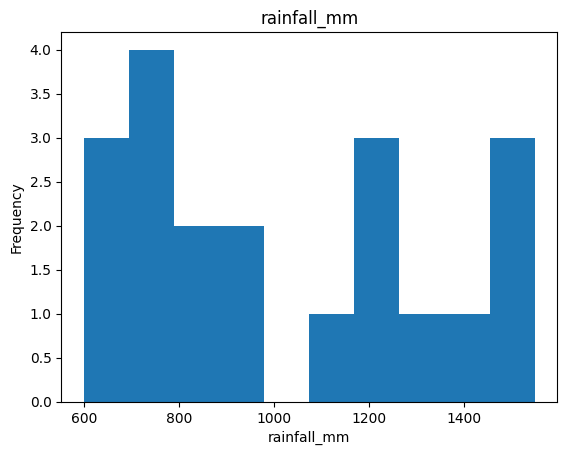

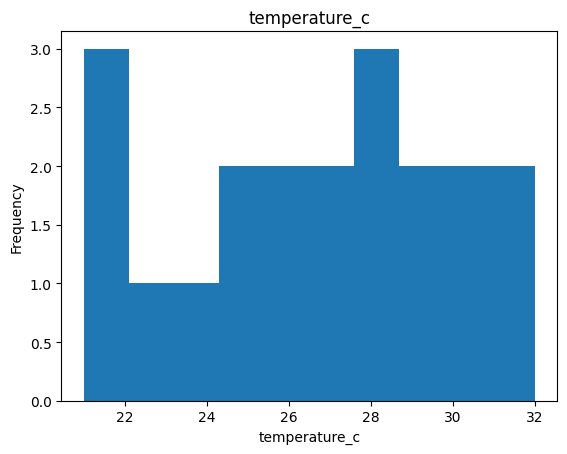

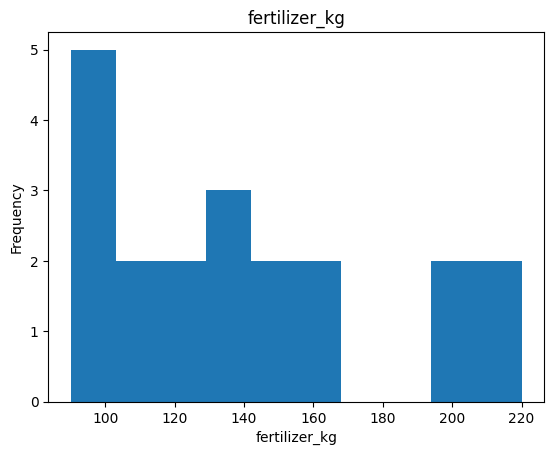

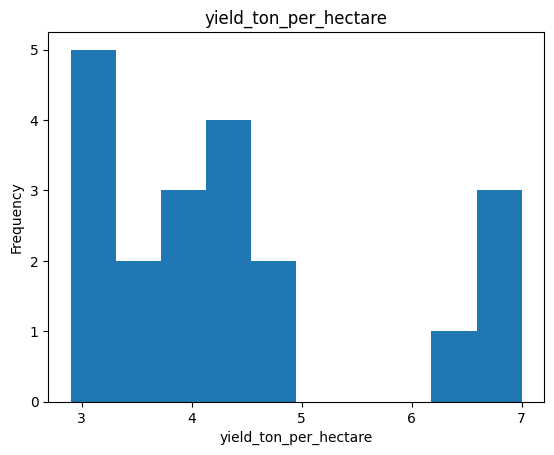

In [14]:
columns = [
    "rainfall_mm",
    "temperature_c",
    "fertilizer_kg",
    "yield_ton_per_hectare"
]

for col in columns:
    plt.hist(df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.show()

Rainfall values are mostly evenly distributed.

Most temperature values lie in the middle range.

Few extreme values are present.

###Q5. Crop Type Analysis
1. Find the number of records for each crop type.

In [15]:
df['crop_type'].value_counts()

,count
crop_type,
Rice,5
Wheat,4
Maize,4
Sugarcane,4
Cotton,3


2. Create a count plot (bar chart) for crop_type.

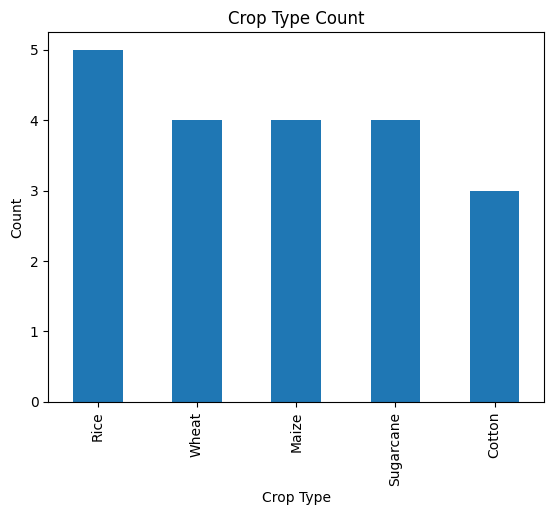

In [16]:
df['crop_type'].value_counts().plot(kind='bar')

plt.xlabel("Crop Type")
plt.ylabel("Count")
plt.title("Crop Type Count")
plt.show()

3. Which crop appears most frequently?

In [17]:
df['crop_type'].mode()[0]

'Rice'

###Q6. Soil Type Analysis
1. Find the frequency of each soil type.

In [18]:
df['soil_type'].value_counts()

,count
soil_type,
Clay,7
Loamy,7
Sandy,6


2. Create a count plot for soil_type.

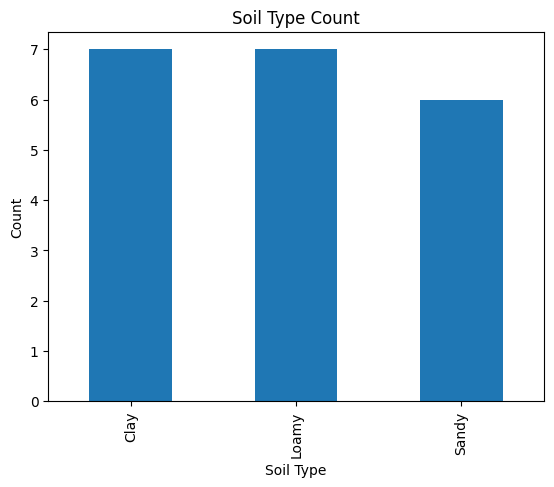

In [19]:
df['soil_type'].value_counts().plot(kind='bar')

plt.xlabel("Soil Type")
plt.ylabel("Count")
plt.title("Soil Type Count")
plt.show()

3. Which soil type is most common?

In [20]:
df['soil_type'].mode()[0]

'Clay'

###Q7. Yield Distribution

Create a histogram of yield_ton_per_hectare.

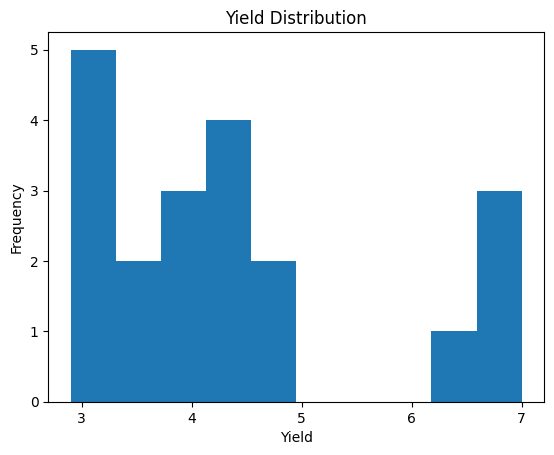

In [21]:
plt.hist(df['yield_ton_per_hectare'])

plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.title("Yield Distribution")
plt.show()

Observations:

1. The distribution of yield_ton_per_hectare is not perfectly normal and shows slight variation in the spread of values.

2. Most yield values are concentrated between approximately 3 to 5 tons per hectare.

3. A few higher yield values around 6.5 to 7 tons per hectare are present, but there are no major noticeable outliers.

###Q8. Scatter Plot Analysis
Create scatter plot:
1. rainfall_mm vs yield_ton_per_hectare

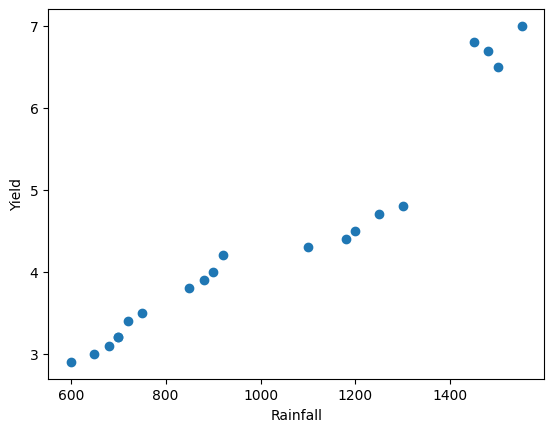

In [22]:
plt.scatter(
    df['rainfall_mm'],
    df['yield_ton_per_hectare']
)

plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.show()

2. fertilizer_kg vs yield_ton_per_hectare

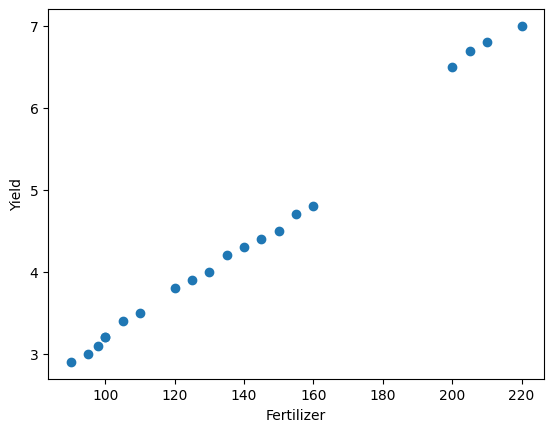

In [23]:
plt.scatter(
    df['fertilizer_kg'],
    df['yield_ton_per_hectare']
)

plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.show()

###Which feature appears to have a stronger relationship with yield?

Observations:

1. Both rainfall_mm and fertilizer_kg show a positive relationship with yield_ton_per_hectare.

2. As rainfall and fertilizer usage increase, the crop yield also increases.

3. Fertilizer_kg appears to have a slightly stronger relationship with yield because the points follow a more clear increasing linear pattern.

###Q9. Correlation Analysis
1. Generate a correlation matrix.

In [24]:
correlation = df.corr(numeric_only=True)

correlation

,rainfall_mm,temperature_c,fertilizer_kg,yield_ton_per_hectare
rainfall_mm,1.000000,0.804474,0.976111,0.954864
temperature_c,0.804474,1.000000,0.789953,0.776428
fertilizer_kg,0.976111,0.789953,1.000000,0.995070
yield_ton_per_hectare,0.954864,0.776428,0.995070,1.000000


2. Create heatmap.

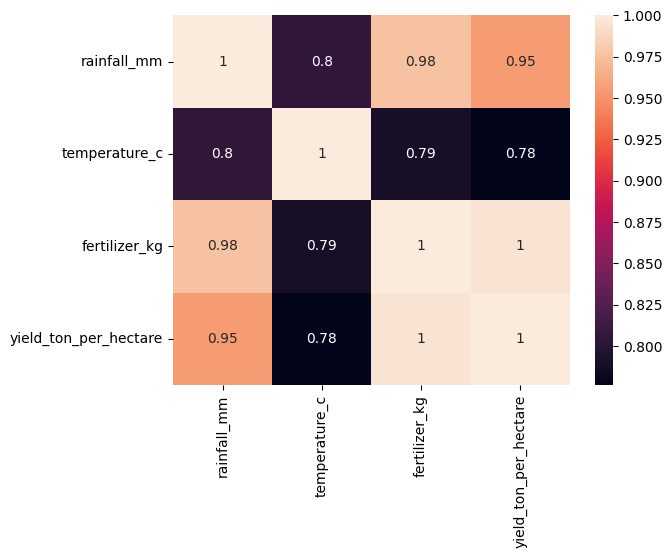

In [25]:
sns.heatmap(correlation, annot=True)

plt.show()

3. Identify top three features most correlated with crop yield.

In [26]:
correlation['yield_ton_per_hectare'].sort_values(
    ascending=False
)

,yield_ton_per_hectare
yield_ton_per_hectare,1.000000
fertilizer_kg,0.995070
rainfall_mm,0.954864
temperature_c,0.776428


###Q10. Group-Based Analysis
1.Calculate average yield for each crop type.

In [27]:
df.groupby('crop_type')['yield_ton_per_hectare'].mean()

,yield_ton_per_hectare
crop_type,
Cotton,3.033333
Maize,3.975000
Rice,4.540000
Sugarcane,6.750000
Wheat,3.300000


2. Calculate average yield for each soil type.

In [28]:
df.groupby('soil_type')['yield_ton_per_hectare'].mean()

,yield_ton_per_hectare
soil_type,
Clay,4.442857
Loamy,5.114286
Sandy,3.500000


3. Which crop has the highest average yield?

In [29]:
df.groupby('crop_type')['yield_ton_per_hectare'].mean().idxmax()

'Sugarcane'

4. Which soil type has the highest average yield?

In [30]:
df.groupby('soil_type')['yield_ton_per_hectare'].mean().idxmax()

'Loamy'

##Part C: Data Preparation
###Q11. Feature Encoding
1. Identify categorical columns.

In [31]:
df.select_dtypes(include='object').columns

Index(['crop_type', 'soil_type'], dtype='object')

2. Convert them into numerical form using One-Hot Encoding.

In [34]:
df_encoded = pd.get_dummies(df)

3. Display first five rows of transformed dataset.

In [33]:
df_encoded.head()

,rainfall_mm,temperature_c,fertilizer_kg,yield_ton_per_hectare,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Sugarcane,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,1200,28,150,4.5,False,False,True,False,False,True,False,False
1,700,22,100,3.2,False,False,False,False,True,False,True,False
2,850,25,120,3.8,False,True,False,False,False,False,False,True
3,1300,29,160,4.8,False,False,True,False,False,True,False,False
4,1500,30,200,6.5,False,False,False,True,False,False,True,False


###Q12. Feature Selection
Separate:

Input features (X)

Target variable (y)

In [35]:
X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)

y = df_encoded['yield_ton_per_hectare']

###Specify target variable.

Target Variable:

yield_ton_per_hectare

##Part D: Machine Learning
###Q13. Train-Test Split

1. Split the dataset into:

80% Training Data

20% Testing Data

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

2. Display the shape:

In [37]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16, 11)
X_test: (4, 11)
y_train: (16,)
y_test: (4,)


###Q14. Linear Regression Model
1. Train a Linear Regression model.

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

2. Display model coefficients and intercept.

In [39]:
print(model.coef_)

print(model.intercept_)

[-8.62194652e-04 -1.07849381e-02  2.58701804e-02 -4.93175870e-01
 -1.80577073e-01  6.93180176e-02  1.08263389e+00 -4.78198963e-01
  9.17046810e-02 -4.20402751e-02 -4.96644058e-02]
1.9230032922840072


3. Which feature has the highest positive coefficient?

In [40]:
pd.Series(
    model.coef_,
    index=X.columns
).idxmax()

'crop_type_Sugarcane'